In [1]:
import pandas as pd
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az # visualization for Bayesian models specifically

/opt/anaconda3/envs/stan311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Added the encoding argument because there was an error parsing the file with utf-8
df = pd.read_csv("/Users/skwanlada/Documents/GitHub/cog-modeling-class-nc-ks/HW4/Speed_Dating_Data.csv", encoding='latin-1')

In [3]:
df.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# Select just the decision and 3 attributes: attractiveness, intelligence, fun
# Plus the participant id and partner id. And drop rows with Nans
data = df[['iid', 'pid','dec','attr', 'intel', 'fun']]
data = data.dropna(subset=['dec','attr', 'intel', 'fun'])

In [5]:
# See the new (relevant-only) data 
data.head()

,iid,pid,dec,attr,intel,fun
0,1,11.0,1,6.0,7.0,7.0
1,1,12.0,1,7.0,7.0,8.0
2,1,13.0,1,5.0,9.0,8.0
3,1,14.0,1,7.0,8.0,7.0
4,1,15.0,1,5.0,7.0,7.0


In [6]:
data

,iid,pid,dec,attr,intel,fun
0,1,11.0,1,6.0,7.0,7.0
1,1,12.0,1,7.0,7.0,8.0
2,1,13.0,1,5.0,9.0,8.0
3,1,14.0,1,7.0,8.0,7.0
4,1,15.0,1,5.0,7.0,7.0
...,...,...,...,...,...,...
8373,552,526.0,0,3.0,5.0,5.0
8374,552,527.0,0,4.0,8.0,4.0
8375,552,528.0,0,4.0,8.0,8.0
8376,552,529.0,0,4.0,5.0,4.0


In [7]:
data_test = data[7157:] # test data 10%
data = data[:7157]      # train data 90%

In [8]:
# Standardize scores by subtracting mean and dividing by SD
cols = ['attr','intel', 'fun']
data[cols] = (data[cols] - data[cols].mean()) / data[cols].std()

/var/folders/wp/tzpzwlds5jv4zlz56mynt1500000gn/T/ipykernel_20000/2309647105.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[cols] = (data[cols] - data[cols].mean()) / data[cols].std()


<Axes: >

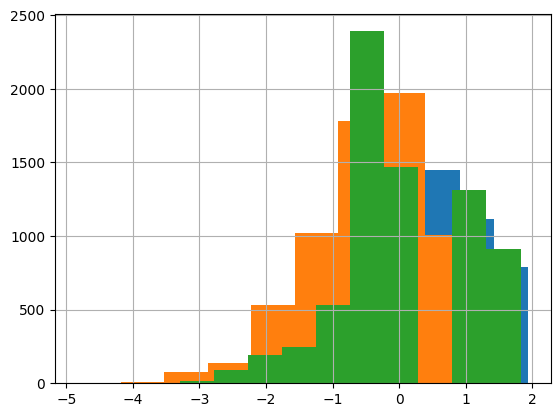

In [9]:
# Plotting each attribute to see which prior(s) are appropriate
# Looks generally Normal(0, 2) from the graphs
data['attr'].hist(bins=10)
data['intel'].hist(bins=10)
data['fun'].hist(bins=10)

In [10]:
data_dict = {
    'N': data.shape[0],
    'y': data['dec'],
    'attr': data['attr'],
    'intel': data['intel'],
    'fun': data['fun'], 
}

In [11]:

model = CmdStanModel(stan_file="./q3.stan")
fit = model.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

20:57:31 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 1:   3%|▎         | 100/3500 [00:00<00:22, 148.10it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [00:01<00:25, 131.51it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [00:02<00:23, 136.56it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:02<00:20, 148.68it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:03<00:20, 147.26it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:04<00:19, 151.53it/s, (Warmup)]



chain 1:  20%|██        | 700/3500 [00:04<00:17, 158.52it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:05<00:16, 165.12it/s, (Warmup)]


chain 1:  26%|██▌       | 900/3500 [00:05<00:14, 175.86it/s, (Warmup)]

chain 1:  29%|██▊       | 1000/3500 [00:06<00:14, 171.22it/s, (Sampling)]





chain 1:  31%|███▏      | 1100/3500 [00:06<00:14, 166.40it/s, (Sampling)]


chain 1:  34%|███▍      | 1200/3500 [00:07<00:14, 163.12it/s, (Sampling


20:57:54 - cmdstanpy - INFO - CmdStan done processing.


In [12]:
print(fit.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [13]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-3776.090000,0.019942,1.383010,1.182230,-3778.850000,-3775.770000,-3774.480000,4840.58,6645.73,74.6451,1.000010
a,1.098060,0.000410,0.040475,0.039848,1.031030,1.098120,1.164450,9759.11,6930.39,150.4920,1.000190
b,-0.128344,0.000368,0.035424,0.035416,-0.186608,-0.127549,-0.070102,9287.69,7020.34,143.2220,1.000010
c,0.617939,0.000411,0.040048,0.040225,0.551961,0.618894,0.683565,9540.92,7848.34,147.1280,0.999964
d,-0.418031,0.000287,0.028272,0.028589,-0.464669,-0.417768,-0.371538,9718.06,7116.28,149.8590,1.000370


In [14]:
fit.summary()['R_hat'].max()

1.00037

In [15]:
fit.summary()['ESS_bulk'].min()

4840.58

In [16]:
fit.summary()['ESS_tail'].min()

6645.73

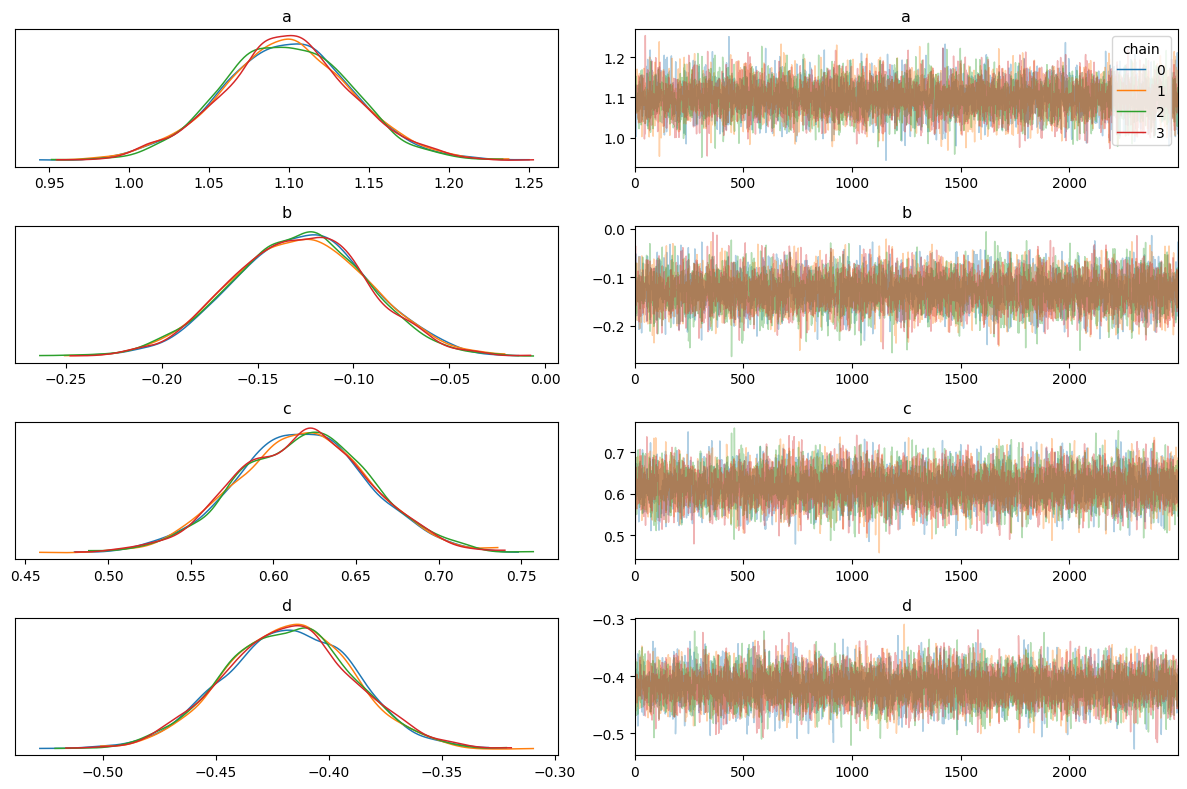

In [17]:
az.plot_trace(fit, var_names=['a', 'b', 'c', 'd'], compact=False, legend=True)
plt.tight_layout()

All R_hat are less than 1.05, and all ESS bulk and tail numbers are greater than 100, which indicates that the model had converged and there does not seem to be any problems or warnings from the diagnostics. The visual inspection confirmed this: the 4 chains overlap well, and there is no movement of the statistics over the iterations. I would conclude that the model converged.

# Extended Model

Next, I extend the model by fitting the regression for each participant individually. Previously, we assumed that each participant prefer or disprefer each of the 3 attributes equally. Now, I will model participant by participant, allowing for more tailored prediction according to how much each participant value each attribute. 

In order to meaningfully measure the predictive performance of the model, I will need the test data to be sliced differently (based on participants—so that each participant has a few held-out test samples.)

The model is implemented in q3_extended.stan file. 

In [18]:
# participant iids already start at 1 and increment by 1
print(f"Number of participants = {data['iid'].max()+1}")
# I used to use data['iid'].nunique() to count unique numbers, but some id skip and I can't find which

Number of participants = 515


In [19]:
data_dict = {
    'N': data.shape[0],
    'J': data['iid'].max() + 1,
    'y': data['dec'],
    'attr': data['attr'],
    'intel': data['intel'],
    'fun': data['fun'], 
    'mask': data['iid']
}

In [20]:
model = CmdStanModel(stan_file="./q3_extended.stan")
fit_extended = model.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

20:57:56 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 1:   3%|▎         | 100/3500 [00:04<02:42, 20.90it/s, (Warmup)]




chain 1:   9%|▊         | 300/3500 [00:14<02:35, 20.64it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:18<02:22, 21.79it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:23<02:17, 21.85it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:27<02:07, 22.69it/s, (Warmup)]



chain 1:  20%|██        | 700/3500 [00:31<02:00, 23.24it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:35<01:52, 23.95it/s, (Warmup)]


chain 1:  26%|██▌       | 900/3500 [00:39<01:43, 25.19it/s, (Warmup)]



chain 1:  29%|██▊       | 1000/3500 [00:43<01:41, 24.67it/s, (Sampling)]



chain 1:  31%|███▏      | 1100/3500 [00:46<01:30, 26.50it/s, (Sampling)]


chain 1:  34%|███▍      | 1200/3500 [00:49<01:22, 27.92it/s, (Sampling)]

chain 1:  37%|███▋      | 1300/3500 [00:52<01:15, 29.01it/s, (Sampling)]


cha


21:01:15 - cmdstanpy - INFO - CmdStan done processing.


In [21]:
print(fit_extended.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [22]:
fit_extended.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-3325.740000,0.573307,33.504600,33.310500,-3381.610000,-3325.480000,-3270.230000,3414.37,6022.08,8.66265,1.000450
a[1],2.010780,0.012329,1.302060,1.294830,-0.058380,1.985050,4.202640,11381.10,6806.98,28.87520,1.000540
a[2],1.318340,0.011791,1.281330,1.281560,-0.736619,1.291270,3.460870,11910.20,7334.40,30.21760,1.000320
a[3],-1.157120,0.015762,1.735100,1.717320,-4.057720,-1.108840,1.647230,12171.40,8282.72,30.88040,1.000190
a[4],1.980130,0.014446,1.401620,1.408930,-0.204951,1.928350,4.349980,9621.18,7508.00,24.41010,1.000180
...,...,...,...,...,...,...,...,...,...,...,...
d[511],0.960421,0.008722,0.863965,0.842981,-0.400881,0.929305,2.408270,9671.14,7463.67,24.53680,0.999918
d[512],-2.707780,0.012734,1.247260,1.225720,-4.814310,-2.653190,-0.742022,9697.65,6642.64,24.60410,1.000330
d[513],0.655886,0.008264,0.840416,0.833167,-0.709215,0.642313,2.052900,10421.60,7850.72,26.44080,1.000350
d[514],-0.922698,0.014193,1.419420,1.409120,-3.295300,-0.913477,1.391540,10075.70,7658.10,25.56320,1.000410
